# Project Objectives

1-Perform deep **exploratory data analysis (EDA)** on the energy consumption dataset.

2-**Engineer** new features from the **date** and existing columns to create meaningful variables for analysis.

3-Identify **patterns**, **trends**, and **relationships** in energy usage across time and load types.

4-Detect **data quality issues** such as missing values, duplicates, inconsistencies, and outliers.

5-Analyze **correlations** among numerical features and determine the features most associated with energy consumption (Usage_kWh).

6-Prepare a clean engineered dataset that can be used for baseline regression modeling in the next stage.

## Import Libraries

In [54]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 


## Load dataset & Basic Dataset Information

In [ ]:
df=pd.read_excel(r"data\Steel Industry Energy.xlsx")

# Display first five rows
df.head()

# Rows and columns
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types")
print(df.dtypes)

print("\nDataset Information")
df.info()


# ============================================
# Summary Statistics
# ============================================

df.describe()

Dataset Shape: (35040, 11)

Column Names:
['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type']

Data Types
date                                     object
Usage_kWh                               float64
Lagging_Current_Reactive.Power_kVarh    float64
Leading_Current_Reactive_Power_kVarh    float64
CO2(tCO2)                               float64
Lagging_Current_Power_Factor            float64
Leading_Current_Power_Factor            float64
NSM                                       int64
WeekStatus                               object
Day_of_week                              object
Load_Type                                object
dtype: object

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM
count,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000
mean,27.386892,13.035384,3.870949,0.011524,80.578056,84.367870,42750.000000
std,33.444380,16.306000,7.424463,0.016151,18.921322,30.456535,24940.534317
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.200000,2.300000,0.000000,0.000000,63.320000,99.700000,21375.000000
50%,4.570000,5.000000,0.000000,0.000000,87.960000,100.000000,42750.000000
75%,51.237500,22.640000,2.090000,0.020000,99.022500,100.000000,64125.000000
max,157.180000,96.910000,27.760000,0.070000,100.000000,100.000000,85500.000000


## Missing values/Duplicates

In [56]:
# ============================================
# Missing Values
# ============================================

missing_values = df.isnull().sum()

print("Missing Values")
print(missing_values)

# ============================================
# Duplicate Rows
# ============================================

duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Missing Values
date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
dtype: int64
Duplicate Rows: 0


# Feature Engineering

### Convert the Date Column

#### Fix Date Column (Day/Month Swap Issue)

The `date` column contains a mix of two formats, which was discovered during 
initial inspection: some rows are stored as native Excel `datetime` objects, 
while others are stored as plain text strings in `DD/MM/YYYY HH:MM` format.

For rows saved as text, parsing is straightforward and unambiguous. However, 
for rows saved as native `datetime` objects, Excel appears to have misinterpreted 
the original `DD/MM/YYYY` format as `MM/DD/YYYY` whenever the day value was 
ambiguous (i.e., day ≤ 12), silently swapping the day and month.

The `fix_date` function below handles both cases:
- **String rows** are parsed directly using the correct `DD/MM/YYYY HH:MM` format.
- **Datetime rows** are checked for the ambiguous day ≤ 12 condition; if met, 
  the day and month values are swapped back to their correct positions. 
  Unambiguous rows (day > 12) are left unchanged, since a swap would have 
  produced an invalid date and therefore could not have occurred.

This correction is essential before extracting any further time-based features 
(hour, month, day of week), since all of them depend on the `date` column being 
accurate.

In [57]:
def fix_date(x):
    if isinstance(x, str):
        # rows stored correctly as text: DD/MM/YYYY HH:MM
        return pd.to_datetime(x, format='%d/%m/%Y %H:%M')
    else:
        # rows Excel stored as native datetime — day/month swapped when day<=12
        if x.day <= 12:
            return pd.Timestamp(year=x.year, month=x.day, day=x.month,
                                 hour=x.hour, minute=x.minute)
        else:
            return x  # unambiguous, already correct

df["date"] = df["date"].apply(fix_date)
print(df["date"].dtype)

datetime64[ns]


## Validate Fixed Date Column

After correcting the day/month swap issue in the `date` column, we cross-check 

our derived day-of-week and weekend/weekday values against the dataset's 

original `Day_of_week` and `WeekStatus` columns. Zero mismatches confirms 

the fix is correct and the `date` column can now be trusted for further 

feature extraction (Hour, Month, etc.). 

In [58]:
mismatch_dow = (df["date"].dt.day_name() != df["Day_of_week"]).sum()
mismatch_ws = ((df["date"].dt.dayofweek >= 5) != (df["WeekStatus"]=="Weekend")).sum()
print("Day_of_week mismatches after fix:", mismatch_dow)
print("WeekStatus mismatches after fix:", mismatch_ws)

Day_of_week mismatches after fix: 0
WeekStatus mismatches after fix: 0


## Create Hour Feature

In [59]:
# ============================================
# Feature Engineering - Hour
# ============================================

# Extract the hour from the date column
df["Hour"] = df["date"].dt.hour

# Display first few values
df[["date", "Hour"]].head()

,date,Hour
0,2018-01-01 00:15:00,0
1,2018-01-01 00:30:00,0
2,2018-01-01 00:45:00,0
3,2018-01-01 01:00:00,1
4,2018-01-01 01:15:00,1


## Extract day name

In [60]:
# Extract day name (Monday, Tuesday, ...)
df["Day_of_Week"] = df["date"].dt.day_name()

## Extract month name

In [61]:
# Extract month name (January, February, ...)
df["Month"] = df["date"].dt.month_name()

## Weekday/Weekend features

In [62]:
# Create Weekday/Weekend feature
df["Week_Status"] = np.where(
    df["date"].dt.dayofweek >= 5,
    "Weekend",
    "Weekday"
)

In [63]:
# Display the new features
df[["date", "Hour", "Day_of_Week", "Month", "Week_Status"]].head()

,date,Hour,Day_of_Week,Month,Week_Status
0,2018-01-01 00:15:00,0,Monday,January,Weekday
1,2018-01-01 00:30:00,0,Monday,January,Weekday
2,2018-01-01 00:45:00,0,Monday,January,Weekday
3,2018-01-01 01:00:00,1,Monday,January,Weekday
4,2018-01-01 01:15:00,1,Monday,January,Weekday


# Power Factor Ratio

In [64]:
# ============================================
# Feature Engineering - Power Factor Ratio
# ============================================

# Ratio of Lagging and Leading Power Factor
df["PowerFactorRatio"] = (
    df["Lagging_Current_Power_Factor"]
    /
    df["Leading_Current_Power_Factor"]
)

df[[
    "Lagging_Current_Power_Factor",
    "Leading_Current_Power_Factor",
    "PowerFactorRatio"
]].head()

,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,PowerFactorRatio
0,73.21,100.0,0.7321
1,66.77,100.0,0.6677
2,70.28,100.0,0.7028
3,68.09,100.0,0.6809
4,64.72,100.0,0.6472


## High Load Feature

In [75]:
# ============================================
# Feature Engineering - HighLoad
# ============================================

# Calculate the 75th percentile of energy usage
threshold = df["Usage_kWh"].quantile(0.75)

# Create a binary HighLoad feature
# 1 = High Load (>= 75th percentile)
# 0 = Normal Load (< 75th percentile)
df["HighLoad"] = np.where(
    df["Usage_kWh"] >= threshold,
    1,
    0
)

# Display first few rows
df[["Usage_kWh", "HighLoad"]].head()

,Usage_kWh,HighLoad
0,3.17,0
1,4.00,0
2,3.24,0
3,3.31,0
4,3.82,0


## Display new Features

In [76]:
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,Month,PowerFactorRatio,HighLoad
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,January,0.7321,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,January,0.6677,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,January,0.7028,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,January,0.6809,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,January,0.6472,0


## Outliers in Usage_kWh

In [77]:
# ============================================
# Detect Outliers using the IQR Method
# ============================================

# Calculate the first (Q1) and third (Q3) quartiles
Q1 = df["Usage_kWh"].quantile(0.25)
Q3 = df["Usage_kWh"].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Define the lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df["Usage_kWh"] < lower_bound) |
              (df["Usage_kWh"] > upper_bound)]

# Print the number of outliers
print("Number of Outliers:", len(outliers))

Number of Outliers: 328


## Visualize Outliers

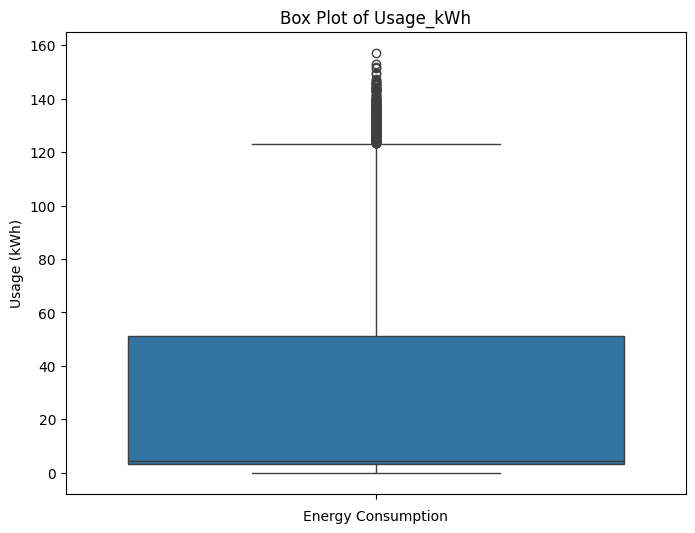

In [68]:
# ============================================
# Box Plot of Usage_kWh
# ============================================

plt.figure(figsize=(8,6))

sns.boxplot(y=df["Usage_kWh"])

plt.title("Box Plot of Usage_kWh")
plt.xlabel("Energy Consumption")
plt.ylabel("Usage (kWh)")

plt.show()

## Correlation Heatmap

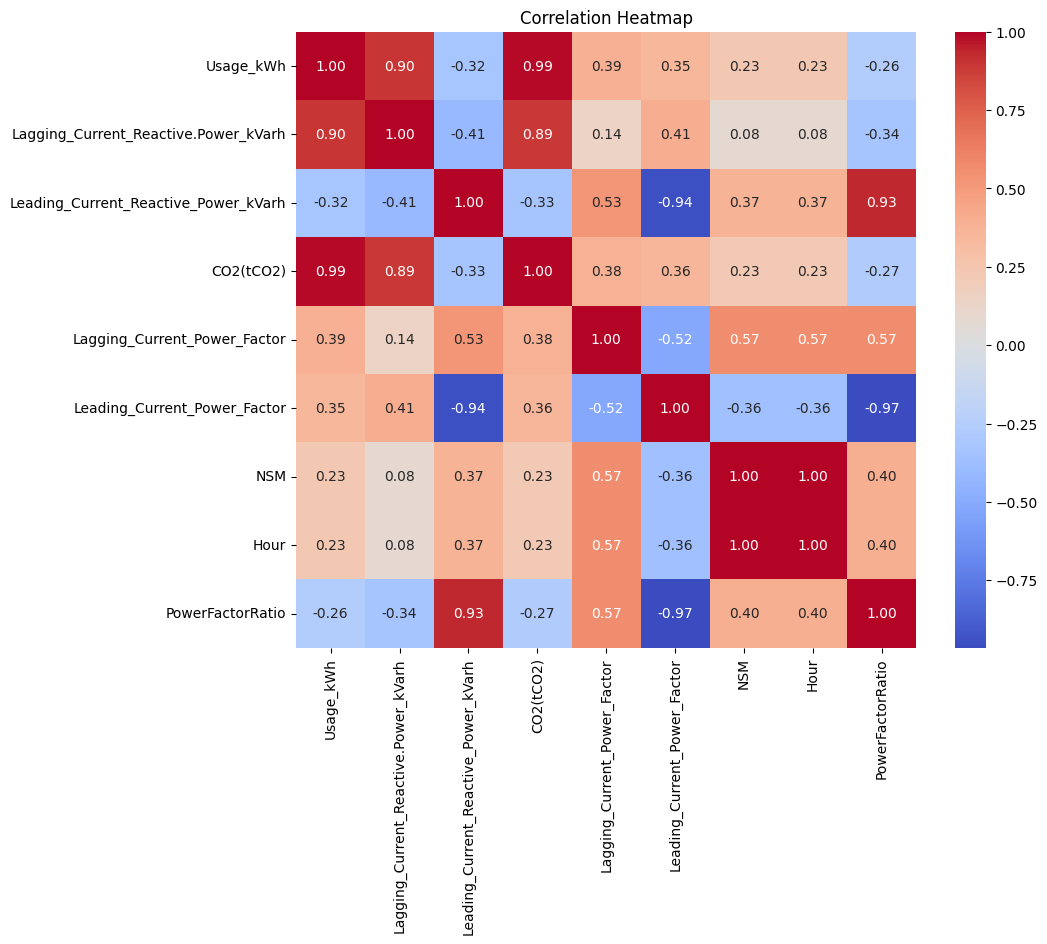

In [69]:
# ============================================
# Correlation Heatmap
# ============================================

# Select only numerical columns
numeric_df = df.select_dtypes(include="number")

# Calculate correlation matrix
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Top 3 Features Correlated with Usage_kWh

In [70]:
# ============================================
# Top 3 Correlated Features
# ============================================

# Get correlation values with Usage_kWh
usage_corr = corr_matrix["Usage_kWh"].drop("Usage_kWh")

# Sort by absolute correlation values
top_features = usage_corr.abs().sort_values(ascending=False).head(3)

print("Top 3 Features Correlated with Usage_kWh\n")
print(top_features)

Top 3 Features Correlated with Usage_kWh

CO2(tCO2)                               0.98818
Lagging_Current_Reactive.Power_kVarh    0.89615
Lagging_Current_Power_Factor            0.38596
Name: Usage_kWh, dtype: float64


## Grouped Bar Chart (Average Energy Consumption by Load Type)

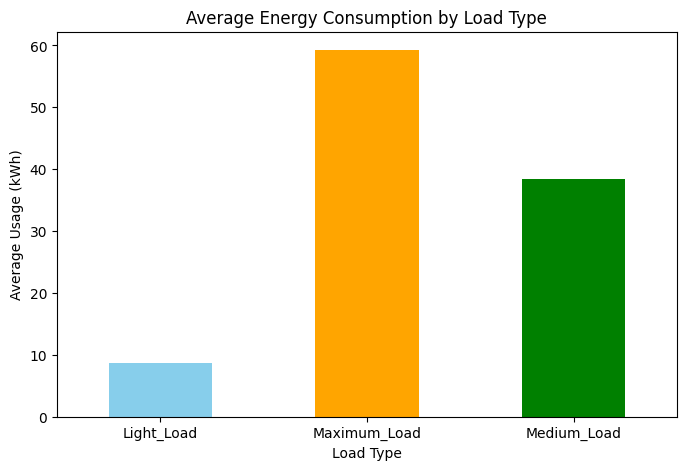

In [71]:
# ============================================
# Average Usage by Load Type
# ============================================

avg_load = df.groupby("Load_Type")["Usage_kWh"].mean()

plt.figure(figsize=(8,5))

avg_load.plot(
    kind="bar",
    color=["skyblue", "orange", "green"]
)

plt.title("Average Energy Consumption by Load Type")
plt.xlabel("Load Type")
plt.ylabel("Average Usage (kWh)")
plt.xticks(rotation=0)

plt.show()

## Line Chart (Average Energy Usage by Hour)

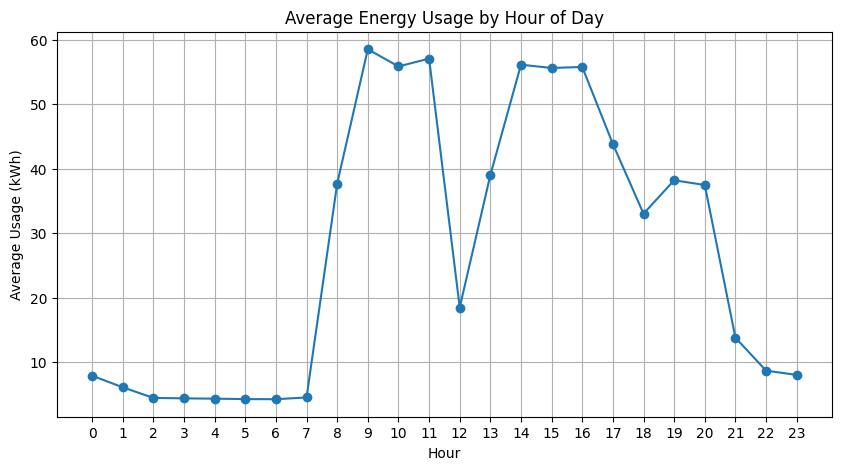

In [72]:
# ============================================
# Average Energy Usage by Hour
# ============================================

hourly_usage = df.groupby("Hour")["Usage_kWh"].mean()

plt.figure(figsize=(10,5))

plt.plot(
    hourly_usage.index,
    hourly_usage.values,
    marker="o"
)

plt.title("Average Energy Usage by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average Usage (kWh)")
plt.xticks(range(24))
plt.grid(True)

plt.show()

## Removing Duplicate Day/Week Columns

1. The dataset already includes `Day_of_week` and `WeekStatus` columns. 
   The task also requires extracting day-of-week and weekday/weekend status 
   from the `date` column, so both were derived independently for comparison.

2. Initial comparison revealed a mismatch between the derived values and the 
   original columns for ~33% of rows. Investigation traced this to a data 
   quality issue in the raw `date` column: Excel stored some rows as native 
   datetime objects with day and month swapped (for ambiguous dates where 
   day <= 12), while other rows were stored correctly as text strings.

3. The `date` column was corrected to account for this swap, and the derived 
   `Day_of_week`/`WeekStatus` values were re-validated against the original 
   columns — resulting in 0 mismatches across all 35,040 rows.

4. Since the derived and original columns are now identical, the derived 
   versions (created only for validation purposes) were dropped to avoid 
   redundancy, and the original `Day_of_week` and `WeekStatus` columns were 
   retained in the final engineered dataset.

In [73]:
df = df.drop(columns=["Day_of_Week", "Week_Status"])

## Save the Engineered Dataset

In [74]:
# ============================================
# Save Engineered Dataset
# ============================================

df.to_csv(
    "data/engineered_energy_dataset.csv",
    index=False
)

print("Engineered dataset saved successfully!")

Engineered dataset saved successfully!


# EDA Summary

Exploring the steel plant energy dataset turned up both some interesting usage 
patterns and one major data issue worth calling out. At first glance, the data 
looked clean — no missing values, no duplicate rows. But a closer look at the 
`date` column revealed a real problem: for about a third of the rows, Excel had 
stored the date in a way that accidentally swapped the day and month whenever 
the day was 12 or lower (since those numbers could be mistaken for a month too). 
The rest of the rows were stored correctly as plain text. This mix-up caused 
11,520 rows to show the wrong day of the week when the date was parsed normally. 
The problem was caught by comparing the day-of-week and weekday/weekend values 
calculated from the date column against the dataset's own `Day_of_week` and 
`WeekStatus` columns. Once the mistake was traced and fixed, the two sets of 
values matched perfectly, with zero differences left.

Using the IQR method, 328 outliers were found in `Usage_kWh`. These were kept 
in the data, since they most likely represent real spikes in factory activity 
rather than data entry mistakes. Looking at correlations, `CO2(tCO2)`, 
`Lagging_Current_Reactive.Power_kVarh`, and `Lagging_Current_Power_Factor` 
stood out as most closely tied to energy usage. That said, `CO2(tCO2)` had an 
almost perfect correlation of 0.988, which is a strong sign that it's not really 
an independent feature — it's more likely just a scaled version of energy usage 
itself. This is something to keep in mind when picking features for the 
modeling stage in Part 2.

The most interesting pattern to come out of this analysis was how clearly energy 
use depends on load type and time of day. Usage during Maximum Load periods was 
noticeably higher than during Medium or Light Load periods, and energy 
consumption peaked sharply during normal working hours before dropping off 
overnight. Put together, this suggests that energy spikes are mainly driven by 
production schedules and machines running at full capacity during the workday, 
along with higher reactive power use when the load is heavy.